# Silent Degradation — reference solution

Predict the risk that a pump fails within 48 h of each snapshot's final
timestamp (its *origin*), scored by Average Precision over 800 snapshots.

**Approach**

1. **Audit the data quirks first**: the `-999.0` outage sentinel, the
   retroactive `maintenance_flag`, repair-downtime rows, and wide per-pump
   baselines.
2. **Clean**: sentinel → NaN → per-series forward/backward fill.
3. **Features**: per-pump *relative* temporal features from each series' own
   recent history (rolling means/stds, short-vs-long trends, 48 h deltas,
   normalization by the 168 h rolling median) — computed identically for the
   training streams and the 168 h test snapshots, using only past data.
4. **Curate training rows**: drop repair-downtime rows and the first 168 h
   warm-up of each stream; drop `maintenance_flag`.
5. **Validate leakage-safely**: GroupKFold by `pump_id`, scored with AP.
6. Train a `HistGradientBoostingClassifier`, predict each snapshot at its
   origin row, write `submission.csv`.

Everything is seeded and deterministic. Only pandas / numpy / scikit-learn /
matplotlib are used (all in the Kaggle Python Docker image).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score
from sklearn.model_selection import GroupKFold

SEED = 0
DATA_DIR = "prepared/public"   # adjust if the public data lives elsewhere

SENSORS = ["vibration_mm_s", "bearing_temp_c", "discharge_pressure_kpa",
           "flow_rate_m3_h", "motor_current_a", "rpm"]
SENTINEL = -999.0
LABEL = "failure_within_48h"

train = pd.read_csv(f"{DATA_DIR}/train.csv", parse_dates=["timestamp"])
test = pd.read_csv(f"{DATA_DIR}/test_features.csv", parse_dates=["timestamp"])
sample_sub = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

print(f"train: {train.shape}, pumps: {train.pump_id.nunique()}, "
      f"positive rate: {train[LABEL].mean():.4f}")
print(f"test:  {test.shape}, snapshots: {test.snapshot_id.nunique()} "
      f"(rows per snapshot: {test.groupby('snapshot_id').size().unique()})")

train: (211200, 12), pumps: 100, positive rate: 0.0421
test:  (134400, 12), snapshots: 800 (rows per snapshot: [168])


## 1. Data audit — find the planted pitfalls before modeling

Three things the problem statement flags, verified empirically:

- **`maintenance_flag` is a retroactive post-incident annotation.** If it were
  used as a feature it would look almost perfect in any training-data
  validation — but the test period is unreviewed, so the column is all zeros
  there. It must be **excluded from the model inputs**.
- **`-999.0` is an outage sentinel**, not a reading.
- **Repair downtime rows** (`rpm == 0`) are stopped-pump readings. Used as
  training examples they teach "low flow/rpm/vibration = safe" — the exact
  opposite of the degradation signature we need — so they are dropped from
  the training matrix (while still being visible to rolling-history
  features, as they are inside test windows too).

In [2]:
# maintenance_flag: how well would it "predict" the training label?
flag_ap = average_precision_score(train[LABEL], train["maintenance_flag"])
print(f"AP of maintenance_flag used directly as a score on train: {flag_ap:.3f}")
print(f"maintenance_flag values in TEST: {sorted(test.maintenance_flag.unique())}")
print("=> near-duplicate of the label in train, constant zero in test: "
      "textbook leakage column. EXCLUDED from features.\n")

# -999.0 sentinel share per channel
sent = {c: float((train[c] == SENTINEL).mean()) for c in SENSORS}
print("share of -999.0 sentinel readings per channel (train):")
for c, v in sent.items():
    print(f"  {c:24s} {v:.4f}")

down = (train["rpm"] == 0.0) & (train["flow_rate_m3_h"] == 0.0)
print(f"\nrepair-downtime rows in train: {int(down.sum()):,} "
      f"({down.mean():.3%}) — dropped from the training matrix")

AP of maintenance_flag used directly as a score on train: 1.000
maintenance_flag values in TEST: [np.int64(0)]
=> near-duplicate of the label in train, constant zero in test: textbook leakage column. EXCLUDED from features.

share of -999.0 sentinel readings per channel (train):
  vibration_mm_s           0.0108
  bearing_temp_c           0.0106
  discharge_pressure_kpa   0.0104
  flow_rate_m3_h           0.0112
  motor_current_a          0.0108
  rpm                      0.0110

repair-downtime rows in train: 8,839 (4.185%) — dropped from the training matrix


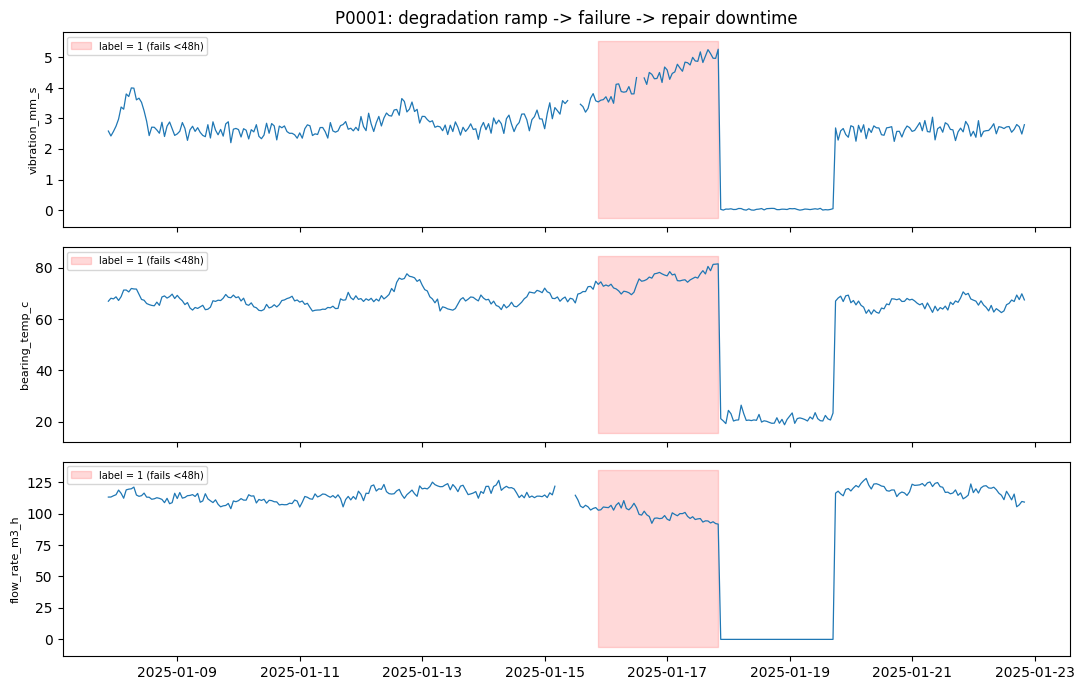

In [3]:
# Visual check: a wear-out failure ramp, the following repair downtime,
# and how wide pump baselines are. Pump chosen deterministically: the first
# pump (sorted) that has a positive label block.
pos_pumps = sorted(train.loc[train[LABEL] == 1, "pump_id"].unique())
pid = pos_pumps[0]
g = train[train.pump_id == pid].sort_values("timestamp").reset_index(drop=True)
first_pos = g.index[g[LABEL] == 1][0]
w = g.iloc[max(0, first_pos - 192): first_pos + 168]
w_clean = w[SENSORS].replace(SENTINEL, np.nan)

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, col in zip(axes, ["vibration_mm_s", "bearing_temp_c", "flow_rate_m3_h"]):
    ax.plot(w["timestamp"], w_clean[col], lw=0.9)
    ax.set_ylabel(col, fontsize=8)
    ax.fill_between(w["timestamp"], *ax.get_ylim(), where=w[LABEL] == 1,
                    alpha=0.15, color="red", label="label = 1 (fails <48h)")
    ax.legend(loc="upper left", fontsize=7)
axes[0].set_title(f"{pid}: degradation ramp -> failure -> repair downtime")
plt.tight_layout(); plt.show()

## 2. Cleaning and per-pump relative features

Healthy baselines differ widely between pumps (installation/duty point), and
benign process transients can raise temperature and vibration *univariately*.
So instead of absolute instantaneous readings, each row gets features that
describe the series **relative to its own recent history**, per channel:

- rolling means (6 h, 24 h) and rolling std (24 h),
- 48 h delta (`value − value 48 h ago`),
- level vs own baseline (`value ÷ |rolling 168 h median|`),
- short-vs-long trend (`mean 6 h − mean 48 h`).

All windows are trailing (past-only), so the same function is applied to the
training streams (grouped by `pump_id`) and to the 168 h test snapshots
(grouped by `snapshot_id`) without any future leakage; test features never
cross snapshot boundaries.

In [4]:
def build_features(df, group_col):
    """Sentinel->NaN, per-series ffill/bfill, then trailing relative features.
    Works identically for train streams (pump_id) and test windows (snapshot_id)."""
    df = df.sort_values([group_col, "timestamp"]).reset_index(drop=True).copy()
    df["is_down"] = (df["rpm"] == 0.0) & (df["flow_rate_m3_h"] == 0.0)
    for c in SENSORS:
        df[c] = df[c].replace(SENTINEL, np.nan)
    for c in SENSORS:                      # impute inside each series only
        df[c] = df.groupby(group_col, sort=False)[c].ffill()
        df[c] = df.groupby(group_col, sort=False)[c].bfill()
    feat_cols = []
    for c in SENSORS:
        gb = df.groupby(group_col, sort=False)[c]
        m6 = gb.rolling(6, min_periods=2).mean().droplevel(0)
        m24 = gb.rolling(24, min_periods=6).mean().droplevel(0)
        m48 = gb.rolling(48, min_periods=12).mean().droplevel(0)
        sd24 = gb.rolling(24, min_periods=6).std().droplevel(0)
        med168 = gb.rolling(168, min_periods=24).median().droplevel(0)
        df[f"{c}_m6"] = m6
        df[f"{c}_m24"] = m24
        df[f"{c}_sd24"] = sd24
        df[f"{c}_diff48"] = df[c] - gb.shift(48)
        df[f"{c}_rel168"] = df[c] / (med168.abs() + 1e-3)
        df[f"{c}_trend"] = m6 - m48
        feat_cols += [c, f"{c}_m6", f"{c}_m24", f"{c}_sd24",
                      f"{c}_diff48", f"{c}_rel168", f"{c}_trend"]
    for col, pref in (("pump_model", "model"), ("site", "site")):
        d = pd.get_dummies(df[col], prefix=pref)
        df = pd.concat([df, d], axis=1)
        feat_cols += list(d.columns)
    return df, feat_cols

tr, feat_cols = build_features(train, "pump_id")
assert "maintenance_flag" not in feat_cols   # leakage column stays out

# training matrix: operating rows only, past the 168 h feature warm-up
tr["hours_in"] = tr.groupby("pump_id").cumcount()
keep = (~tr["is_down"]) & (tr["hours_in"] >= 168)
X, y = tr.loc[keep, feat_cols], tr.loc[keep, LABEL].to_numpy()
groups = tr.loc[keep, "pump_id"].to_numpy()
print(f"training matrix: {X.shape}, positive rate {y.mean():.4f}, "
      f"{len(feat_cols)} features")

training matrix: (185865, 48), positive rate 0.0452, 48 features


## 3. Leakage-safe validation: GroupKFold by pump

Adjacent hourly rows of one pump are near-duplicates; a shuffled row-level
K-fold would put them on both sides of the split and grossly overstate
performance (with `maintenance_flag` included it reports AP ≈ 1.0). Splitting
**by pump** keeps every pump's rows in a single fold, matching the evaluation
setting (unseen pumps). Validation uses AP — the evaluation metric — which is
also threshold-free and appropriate for the ~4.5% positive rate; the model
additionally receives balanced class weights.

In [5]:
def make_model():
    return HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.06, max_leaf_nodes=31,
        min_samples_leaf=40, l2_regularization=1.0,
        class_weight="balanced", early_stopping=False, random_state=SEED)

cv = GroupKFold(n_splits=4)
oof = np.zeros(len(y))
for i, (itr, iva) in enumerate(cv.split(X, y, groups)):
    m = make_model().fit(X.iloc[itr], y[itr])
    oof[iva] = m.predict_proba(X.iloc[iva])[:, 1]
    print(f"fold {i}: AP = {average_precision_score(y[iva], oof[iva]):.4f} "
          f"({len(np.unique(groups[iva]))} held-out pumps)")
cv_ap = average_precision_score(y, oof)
print(f"\nGroupKFold out-of-fold AP = {cv_ap:.4f} "
      f"(constant baseline = {y.mean():.4f})")

fold 0: AP = 0.6951 (25 held-out pumps)


fold 1: AP = 0.6104 (25 held-out pumps)


fold 2: AP = 0.8011 (25 held-out pumps)


fold 3: AP = 0.6614 (25 held-out pumps)

GroupKFold out-of-fold AP = 0.6854 (constant baseline = 0.0452)


## 4. Final model and predictions at each snapshot origin

Fit on all curated training rows, rebuild the identical features inside each
168 h test snapshot, and score the **last row** (the prediction origin) of
each snapshot.

Note the expectations set by the data: a substantial minority of failures are
sudden, with no sensor precursor — those positives are irreducibly
indistinguishable from healthy pumps, so out-of-fold AP around ~0.7 is near
the practical ceiling and we do not chase it with extra complexity.

In [6]:
model = make_model().fit(X, y)

te, _ = build_features(test, "snapshot_id")
origins = te.groupby("snapshot_id", sort=False).tail(1)      # 1 row/snapshot
pred = model.predict_proba(origins[feat_cols])[:, 1]

submission = (pd.DataFrame({"snapshot_id": origins["snapshot_id"].to_numpy(),
                            "prediction": pred})
              .sort_values("snapshot_id").reset_index(drop=True))

# format checks against the provided sample
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub) == 800
assert set(submission.snapshot_id) == set(sample_sub.snapshot_id)
assert submission.prediction.between(0, 1).all()        and np.isfinite(submission.prediction).all()

submission.to_csv("submission.csv", index=False)
print("submission.csv written")
print(submission.head())
print(f"\nprediction stats: min {submission.prediction.min():.4f}, "
      f"max {submission.prediction.max():.4f}, "
      f"mean {submission.prediction.mean():.4f}")

submission.csv written
  snapshot_id  prediction
0   snap_0001    0.036602
1   snap_0002    0.999477
2   snap_0003    0.000075
3   snap_0004    0.007142
4   snap_0005    0.000368

prediction stats: min 0.0001, max 0.9999, mean 0.1237


## 5. Summary

- `maintenance_flag` identified as retroactive leakage (AP ≈ 1 on train,
  all-zero in test) and **excluded**; `-999.0` sentinels imputed within each
  series; repair-downtime rows dropped from the training matrix.
- Per-pump relative/trend features over 6–168 h trailing windows handle the
  wide healthy-baseline spread and univariate benign transients.
- GroupKFold-by-pump validation (out-of-fold AP above) is the honest estimate
  of performance on unseen pumps; sudden no-precursor failures cap what any
  model can reach.
- Deterministic end-to-end: fixed seeds, no sampling outside seeded RNGs.